# PERTANYAAN BISNIS

1. Berapakah rata-rata penurunan skor kesehatan harian **(Overall_Health_Score)** dan persentase peningkatan risiko gangguan pencernaan **(Digestive_Issues = Yes)** pada kelompok masyarakat yang mengonsumsi fast food lebih dari 5 kali seminggu **(Fast_Food_Meals_Per_Week > 5)** dibandingkan dengan kelompok yang mengonsumsi kurang dari 2 kali seminggu, berdasarkan data historis saat ini?
2. Berapa proporsi responden yang memiliki asupan kalori harian di atas batas normal **(Average_Daily_Calories > 2500)** namun masih memiliki tingkat energi yang rendah **(Energy_Level_Score < 5)**, dan bagaimana hubungannya dengan frekuensi makan fast food mereka?
3. Kelompok rentang usia **(Age)** manakah yang menunjukkan kombinasi tren paling berisiko tinggi—yaitu memiliki frekuensi fast food **(Fast_Food_Meals_Per_Week)** tertinggi sekaligus memiliki jumlah kunjungan ke dokter **(Doctor_Visits_Per_Year)** terbanyak dalam periode pengamatan dataset ini?
4. Apakah terdapat korelasi positif yang signifikan antara kombinasi tingginya frekuensi fast food **(Fast_Food_Meals_Per_Week)** dan rendahnya jam olahraga **(Physical_Activity_Hours_Per_Week)** terhadap tingginya nilai BMI masyarakat dalam dataset saat ini?

In [89]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [90]:
df = pd.read_csv('/content/drive/MyDrive/fast_food_consumption.csv')

# ASESSING DATA

In [91]:
df.head(15)

,Age,Gender,Fast_Food_Meals_Per_Week,Average_Daily_Calories,BMI,Physical_Activity_Hours_Per_Week,Sleep_Hours_Per_Day,Energy_Level_Score,Digestive_Issues,Doctor_Visits_Per_Year,Overall_Health_Score
0,54.930548,Male,1.178096,3175.712809,28.182156,4.365608,7.786014,8.925827,No,7.147365,5.090828
1,45.128748,Male,11.762039,1778.084294,22.949542,9.577804,6.805357,2.247784,No,4.041624,2.861251
2,31.537499,NaN,7.656805,NaN,21.331324,3.582319,7.382172,1.570133,Yes,6.976890,3.838262
3,23.816191,Female,6.078579,2596.031149,26.720618,8.746621,6.187714,6.024728,No,6.891923,8.111511
4,38.588798,Female,13.991759,2282.317887,18.019364,2.089211,7.647052,6.812165,No,4.842839,4.029074
5,55.704012,Female,6.868890,3235.833761,18.332442,6.613853,8.077511,7.139280,No,0.922283,9.050723
6,35.959702,Male,13.828475,1962.767495,21.632407,9.860599,4.728941,9.036098,No,6.936869,8.960829
7,39.577046,NaN,10.094878,2984.217920,18.407192,1.115078,8.092750,6.001399,Yes,10.111786,6.014450
8,28.023415,Female,1.517950,1861.562498,19.823331,0.141455,6.758180,8.033689,Yes,NaN,1.966420
9,28.133523,Male,6.059391,2256.214263,23.598635,4.351144,NaN,6.130385,No,4.956974,7.089773


In [92]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 11 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Age                               785 non-null    float64
 1   Gender                            784 non-null    object 
 2   Fast_Food_Meals_Per_Week          784 non-null    float64
 3   Average_Daily_Calories            785 non-null    float64
 4   BMI                               784 non-null    float64
 5   Physical_Activity_Hours_Per_Week  785 non-null    float64
 6   Sleep_Hours_Per_Day               786 non-null    float64
 7   Energy_Level_Score                785 non-null    float64
 8   Digestive_Issues                  784 non-null    object 
 9   Doctor_Visits_Per_Year            784 non-null    float64
 10  Overall_Health_Score              786 non-null    float64
dtypes: float64(9), object(2)
memory usage: 68.9+ KB


In [93]:
df.isnull().sum()

,0
Age,15
Gender,16
Fast_Food_Meals_Per_Week,16
Average_Daily_Calories,15
BMI,16
Physical_Activity_Hours_Per_Week,15
Sleep_Hours_Per_Day,14
Energy_Level_Score,15
Digestive_Issues,16
Doctor_Visits_Per_Year,16


In [94]:
df.duplicated().sum()

np.int64(25)

In [95]:
df.describe()

,Age,Fast_Food_Meals_Per_Week,Average_Daily_Calories,BMI,Physical_Activity_Hours_Per_Week,Sleep_Hours_Per_Day,Energy_Level_Score,Doctor_Visits_Per_Year,Overall_Health_Score
count,785.000000,784.000000,785.000000,784.000000,785.000000,786.000000,785.000000,784.000000,786.000000
mean,42.263112,8.053398,2700.985204,27.861658,5.728570,6.885378,5.610921,6.596444,5.651200
std,19.954118,7.170116,915.467690,8.278926,4.805375,2.398823,4.287073,5.646888,4.421605
min,15.924355,-0.654967,1557.114919,17.484201,-0.168094,3.830348,0.730086,-0.489262,0.627781
25%,29.169390,3.228965,2110.748709,22.631988,2.474270,5.271507,2.886780,3.014331,2.823314
50%,40.566447,7.036763,2563.322941,26.777662,5.151715,6.688430,5.004622,6.027589,5.054822
75%,50.682745,11.075144,3093.386614,31.121691,7.843612,7.844644,7.151115,9.008142,7.861607
max,120.326435,36.185476,6298.984038,60.366170,24.600790,16.319222,22.320321,28.533292,22.849587


# CLEANING DATA

In [96]:
df.drop_duplicates(inplace=True)
df.duplicated().sum()

np.int64(0)

In [97]:
num_cols = df.select_dtypes(include=[np.number]).columns
for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 775 entries, 0 to 799
Data columns (total 11 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Age                               775 non-null    float64
 1   Gender                            759 non-null    object 
 2   Fast_Food_Meals_Per_Week          775 non-null    float64
 3   Average_Daily_Calories            775 non-null    float64
 4   BMI                               775 non-null    float64
 5   Physical_Activity_Hours_Per_Week  775 non-null    float64
 6   Sleep_Hours_Per_Day               775 non-null    float64
 7   Energy_Level_Score                775 non-null    float64
 8   Digestive_Issues                  760 non-null    object 
 9   Doctor_Visits_Per_Year            775 non-null    float64
 10  Overall_Health_Score              775 non-null    float64
dtypes: float64(9), object(2)
memory usage: 72.7+ KB


In [98]:
cat_cols = df.select_dtypes(include=['object']).columns
for cat in cat_cols:
    df[cat] = df[cat].fillna(df[cat].mode()[0])

df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 775 entries, 0 to 799
Data columns (total 11 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Age                               775 non-null    float64
 1   Gender                            775 non-null    object 
 2   Fast_Food_Meals_Per_Week          775 non-null    float64
 3   Average_Daily_Calories            775 non-null    float64
 4   BMI                               775 non-null    float64
 5   Physical_Activity_Hours_Per_Week  775 non-null    float64
 6   Sleep_Hours_Per_Day               775 non-null    float64
 7   Energy_Level_Score                775 non-null    float64
 8   Digestive_Issues                  775 non-null    object 
 9   Doctor_Visits_Per_Year            775 non-null    float64
 10  Overall_Health_Score              775 non-null    float64
dtypes: float64(9), object(2)
memory usage: 72.7+ KB


In [99]:
df.describe()

,Age,Fast_Food_Meals_Per_Week,Average_Daily_Calories,BMI,Physical_Activity_Hours_Per_Week,Sleep_Hours_Per_Day,Energy_Level_Score,Doctor_Visits_Per_Year,Overall_Health_Score
count,775.000000,775.000000,775.000000,775.000000,775.000000,775.000000,775.000000,775.000000,775.000000
mean,39.703353,7.121905,2581.973701,26.784233,5.104056,6.575925,5.059542,5.876126,5.084465
std,14.142451,5.060143,645.783930,5.838636,3.392397,1.693256,3.049873,4.025288,3.156104
min,15.924355,-0.654967,1557.114919,17.484201,-0.168094,3.830348,0.730086,-0.489262,0.627781
25%,28.919689,3.189006,2103.825617,22.592571,2.461098,5.251375,2.864653,3.005004,2.812570
50%,40.114448,6.890553,2548.722289,26.462182,4.915682,6.601093,4.972040,5.982336,4.989809
75%,49.625574,10.846596,3042.583311,30.690015,7.447314,7.682962,7.048787,8.844268,7.101968
max,120.326435,36.185476,6298.984038,60.366170,24.600790,16.319222,22.320321,28.533292,22.849587


In [100]:
num_cols = df.select_dtypes(include=['number'])
Q1 = num_cols.quantile(0.25)
Q3 = num_cols.quantile(0.75)
IQR = Q3 - Q1

df = df[~((num_cols < (Q1 - 3 * IQR)) | (num_cols > (Q3 + 3 * IQR))).any(axis=1)]

df.describe()

,Age,Fast_Food_Meals_Per_Week,Average_Daily_Calories,BMI,Physical_Activity_Hours_Per_Week,Sleep_Hours_Per_Day,Energy_Level_Score,Doctor_Visits_Per_Year,Overall_Health_Score
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,38.968507,6.857003,2548.094701,26.478148,4.926351,6.487119,4.902217,5.669615,4.922544
std,11.915151,4.249638,541.849514,4.900473,2.848261,1.420913,2.577353,3.409263,2.673076
min,15.924355,-0.654967,1557.114919,17.484201,-0.168094,3.830348,0.730086,-0.489262,0.627781
25%,28.711837,3.170256,2101.467040,22.584664,2.440511,5.237354,2.850779,2.987408,2.799762
50%,40.114448,6.890553,2548.722289,26.462182,4.915682,6.601093,4.972040,5.982336,4.989809
75%,49.411727,10.738731,3021.846762,30.586130,7.430143,7.647576,7.029297,8.735006,7.074336
max,60.115063,14.599912,3535.298548,35.433720,10.269428,9.150143,9.325183,11.276876,9.355770


In [101]:
df['Age'] = df['Age'].round().astype(int)
df['Fast_Food_Meals_Per_Week'] = df['Fast_Food_Meals_Per_Week'].round().astype(int)
df['Average_Daily_Calories'] = df['Average_Daily_Calories'].round().astype(int)
df['Energy_Level_Score'] = df['Energy_Level_Score'].round().astype(int)
df['Doctor_Visits_Per_Year'] = df['Doctor_Visits_Per_Year'].round().astype(int)
df['BMI'] = df['BMI'].round(1)
df['Physical_Activity_Hours_Per_Week'] = df['Physical_Activity_Hours_Per_Week'].round(1)
df['Sleep_Hours_Per_Day'] = df['Sleep_Hours_Per_Day'].round(1)
df['Overall_Health_Score'] = df['Overall_Health_Score'].round(1)

df.head()

,Age,Gender,Fast_Food_Meals_Per_Week,Average_Daily_Calories,BMI,Physical_Activity_Hours_Per_Week,Sleep_Hours_Per_Day,Energy_Level_Score,Digestive_Issues,Doctor_Visits_Per_Year,Overall_Health_Score
0,55,Male,1,3176,28.2,4.4,7.8,9,No,7,5.1
1,45,Male,12,1778,22.9,9.6,6.8,2,No,4,2.9
2,32,Female,8,2549,21.3,3.6,7.4,2,Yes,7,3.8
3,24,Female,6,2596,26.7,8.7,6.2,6,No,7,8.1
4,39,Female,14,2282,18.0,2.1,7.6,7,No,5,4.0


In [102]:
df.describe()

,Age,Fast_Food_Meals_Per_Week,Average_Daily_Calories,BMI,Physical_Activity_Hours_Per_Week,Sleep_Hours_Per_Day,Energy_Level_Score,Doctor_Visits_Per_Year,Overall_Health_Score
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,38.970052,6.859375,2548.101562,26.478516,4.926953,6.487240,4.897135,5.654948,4.923568
std,11.923721,4.246758,541.862008,4.899357,2.848123,1.421136,2.574793,3.406329,2.672752
min,16.000000,-1.000000,1557.000000,17.500000,-0.200000,3.800000,1.000000,0.000000,0.600000
25%,29.000000,3.000000,2101.500000,22.600000,2.475000,5.200000,3.000000,3.000000,2.800000
50%,40.000000,7.000000,2549.000000,26.500000,4.900000,6.600000,5.000000,6.000000,5.000000
75%,49.000000,11.000000,3022.000000,30.600000,7.400000,7.600000,7.000000,9.000000,7.100000
max,60.000000,15.000000,3535.000000,35.400000,10.300000,9.200000,9.000000,11.000000,9.400000


# FEATURE ENGINERING

In [103]:
df['Fast_Food_Group'] = 'Normal'
df.loc[df['Fast_Food_Meals_Per_Week'] > 5, 'Fast_Food_Group'] = 'Tinggi (>5x)'
df.loc[df['Fast_Food_Meals_Per_Week'] < 2, 'Fast_Food_Group'] = 'Rendah (<2x)'

print("Distribusi Kelompok Fast Food:")
df['Fast_Food_Group'].value_counts()

Distribusi Kelompok Fast Food:


,count
Fast_Food_Group,
Tinggi (>5x),456
Normal,210
Rendah (<2x),102


In [104]:
df['High_Cal_Low_Energy'] = (df['Average_Daily_Calories'] > 2500) & (df['Energy_Level_Score'] < 5)
df['High_Cal_Low_Energy'] = df['High_Cal_Low_Energy'].map({True: 'Ya', False: 'Tidak'})

print("Jumlah responden berisiko (Kalori Tinggi & Energi Rendah):")
df['High_Cal_Low_Energy'].value_counts()

Jumlah responden berisiko (Kalori Tinggi & Energi Rendah):


,count
High_Cal_Low_Energy,
Tidak,586
Ya,182


In [105]:
age_bins = [-1, 19, 29, 44, 59, 120]
age_labels = ['<20 Tahun', '20-29 Tahun', '30-44 Tahun', '45-59 Tahun', '60+ Tahun']

df['Age_Group'] = pd.cut(df['Age'], bins=age_bins, labels=age_labels)

print("Jumlah responden per kelompok usia:")
df['Age_Group'].value_counts().sort_index()

Jumlah responden per kelompok usia:


,count
Age_Group,
<20 Tahun,41
20-29 Tahun,159
30-44 Tahun,288
45-59 Tahun,278
60+ Tahun,2


# EXPLORATORY DATA

## Q1

In [106]:
df['Digestive_Numeric'] = df['Digestive_Issues'].map({'Yes': 1, 'No': 0})

In [107]:
Q1_analisis = df.groupby('Fast_Food_Group').agg(
    Rata_Skor_Kesehatan=('Overall_Health_Score', 'mean'),
    Persen_Gangguan_Pencernaan=('Digestive_Numeric', lambda x: x.mean() * 100)
).loc[['Rendah (<2x)', 'Tinggi (>5x)']]

Q1_analisis.round(2)

,Rata_Skor_Kesehatan,Persen_Gangguan_Pencernaan
Fast_Food_Group,,
Rendah (<2x),5.01,36.27
Tinggi (>5x),4.96,35.53


## Q2

In [108]:
total_responden = len(df)
jumlah_berisiko = len(df[df['High_Cal_Low_Energy'] == 'Ya'])
persentase_berisiko = (jumlah_berisiko / total_responden) * 100

print(f"Total Responden: {total_responden} orang")
print(f"Jumlah Responden Berisiko: {jumlah_berisiko} orang")
print(f"Proporsi Responden Berisiko: {persentase_berisiko:.2f}%")

Total Responden: 768 orang
Jumlah Responden Berisiko: 182 orang
Proporsi Responden Berisiko: 23.70%


## Q3

In [109]:
Q3_analisis = df.groupby('Age_Group', observed=False).agg(
    Rata_Fast_Food_Per_Minggu=('Fast_Food_Meals_Per_Week', 'mean'),
    Rata_Kunjungan_Dokter_Per_Tahun=('Doctor_Visits_Per_Year', 'mean')
).sort_index()

Q3_analisis.round(2)

,Rata_Fast_Food_Per_Minggu,Rata_Kunjungan_Dokter_Per_Tahun
Age_Group,,
<20 Tahun,7.00,5.27
20-29 Tahun,6.91,5.58
30-44 Tahun,6.84,5.76
45-59 Tahun,6.87,5.64
60+ Tahun,1.00,6.50


## Q4

In [110]:
variabel_terkait = ['Fast_Food_Meals_Per_Week', 'Physical_Activity_Hours_Per_Week', 'BMI']
matriks_korelasi = df[variabel_terkait].corr()

print("Matriks Korelasi Q4:")
matriks_korelasi.round(2)

Matriks Korelasi Q4:


,Fast_Food_Meals_Per_Week,Physical_Activity_Hours_Per_Week,BMI
Fast_Food_Meals_Per_Week,1.00,-0.06,-0.05
Physical_Activity_Hours_Per_Week,-0.06,1.00,-0.04
BMI,-0.05,-0.04,1.00


# VISUALISASI DATA

## Q1

/tmp/ipykernel_8496/4121577666.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(ax=axes[0], x=Q1_analisis.index, y='Rata_Skor_Kesehatan', data=Q1_analisis, palette='coolwarm')
/tmp/ipykernel_8496/4121577666.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(ax=axes[1], x=Q1_analisis.index, y='Persen_Gangguan_Pencernaan', data=Q1_analisis, palette='Oranges')


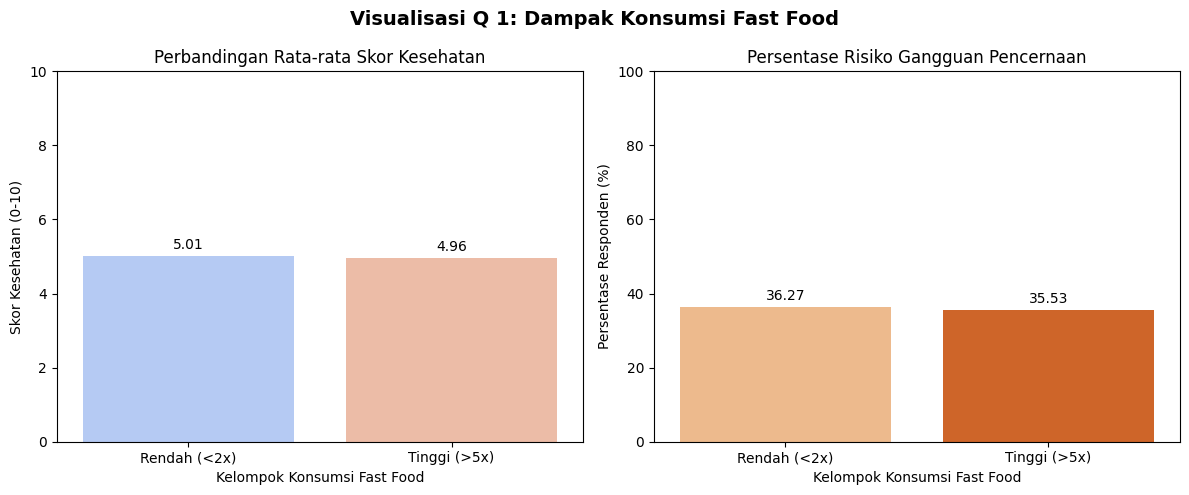

In [111]:
Q1 = Q1_analisis.reset_index()
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.barplot(ax=axes[0], x=Q1_analisis.index, y='Rata_Skor_Kesehatan', data=Q1_analisis, palette='coolwarm')
axes[0].set_title('Perbandingan Rata-rata Skor Kesehatan')
axes[0].set_xlabel('Kelompok Konsumsi Fast Food')
axes[0].set_ylabel('Skor Kesehatan (0-10)')
axes[0].set_ylim(0, 10)
axes[0].bar_label(axes[0].containers[0], fmt='%.2f', padding=3)
axes[0].bar_label(axes[0].containers[1], fmt='%.2f', padding=3)

sns.barplot(ax=axes[1], x=Q1_analisis.index, y='Persen_Gangguan_Pencernaan', data=Q1_analisis, palette='Oranges')
axes[1].set_title('Persentase Risiko Gangguan Pencernaan')
axes[1].set_xlabel('Kelompok Konsumsi Fast Food')
axes[1].set_ylabel('Persentase Responden (%)')
axes[1].set_ylim(0, 100)
axes[1].bar_label(axes[1].containers[0], fmt='%.2f', padding=3)
axes[1].bar_label(axes[1].containers[1], fmt='%.2f', padding=3)

plt.suptitle('Visualisasi Q 1: Dampak Konsumsi Fast Food', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## Q2

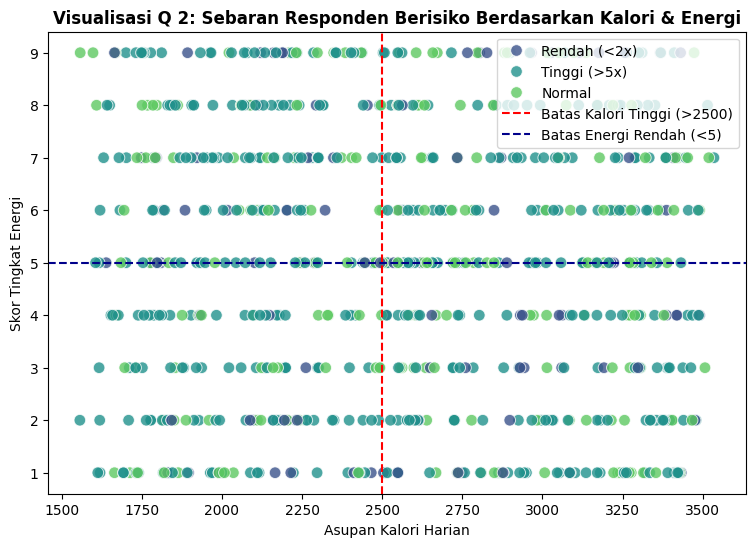

In [112]:
plt.figure(figsize=(9, 6))

# Membuat scatter plot, warna titik ditentukan oleh frekuensi fast food (hue)
sns.scatterplot(data=df, x='Average_Daily_Calories', y='Energy_Level_Score',
                hue='Fast_Food_Group', palette='viridis', alpha=0.8, s=70)

plt.axvline(x=2500, color='red', linestyle='--', linewidth=1.5, label='Batas Kalori Tinggi (>2500)')
plt.axhline(y=5, color='darkblue', linestyle='--', linewidth=1.5, label='Batas Energi Rendah (<5)')

plt.title('Visualisasi Q 2: Sebaran Responden Berisiko Berdasarkan Kalori & Energi', fontsize=12, fontweight='bold')
plt.xlabel('Asupan Kalori Harian')
plt.ylabel('Skor Tingkat Energi')
plt.legend(loc='upper right')
plt.show()

## Q3

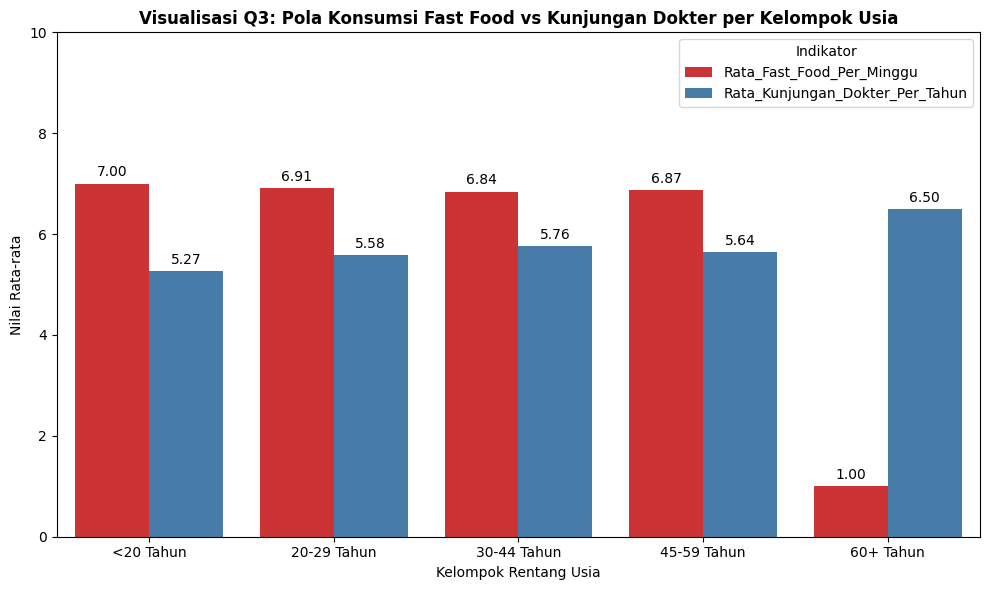

In [113]:
Q3_melted = Q3_analisis.reset_index().melt(
    id_vars='Age_Group',
    value_vars=['Rata_Fast_Food_Per_Minggu', 'Rata_Kunjungan_Dokter_Per_Tahun'],
    var_name='Indikator_Kesehatan',
    value_name='Rata_Rata_Nilai'
)

plt.figure(figsize=(10, 6))
sns.barplot(data=Q3_melted, x='Age_Group', y='Rata_Rata_Nilai', hue='Indikator_Kesehatan', palette='Set1')
plt.title('Visualisasi Q3: Pola Konsumsi Fast Food vs Kunjungan Dokter per Kelompok Usia', fontsize=12, fontweight='bold')
plt.xlabel('Kelompok Rentang Usia')
plt.ylabel('Nilai Rata-rata')
plt.bar_label(plt.gca().containers[0], fmt='%.2f', padding=3)
plt.bar_label(plt.gca().containers[1], fmt='%.2f', padding=3)
plt.ylim(0, 10)
plt.xticks(rotation=0)
plt.legend(title='Indikator')
plt.tight_layout()
plt.show()

## Q4

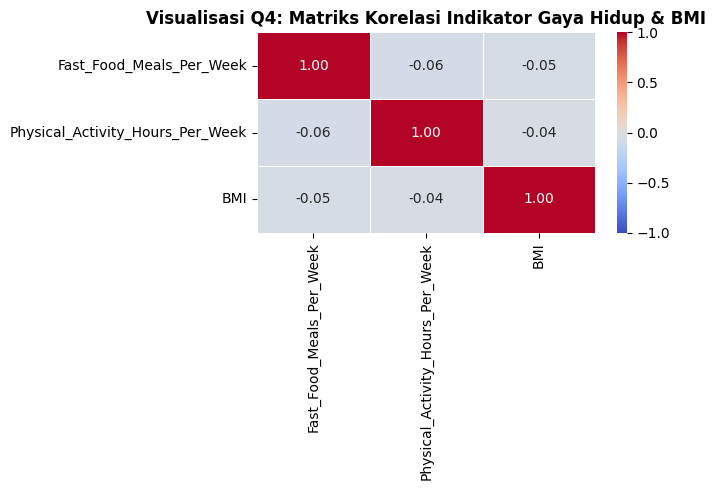

In [114]:
plt.figure(figsize=(7, 5))
sns.heatmap(matriks_korelasi, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1, linewidths=0.5)

plt.title('Visualisasi Q4: Matriks Korelasi Indikator Gaya Hidup & BMI', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

# EXPLANATORY DATA ANALISIS

## Q1
Berdasarakn hasil visualisasi menunjukkan bahwa perbandingan skor kesehatan terhadap kelompok konsumsi fastfood menunjukkann skor 5,01 untuk kelompok yang memiliki konsumsi fasfood rendah (<2), sedangkan untuk kelompok dengan konsumsi fastfood tinggi (>5) menunjukkan skor yang lebih rendah yaitu 4,96 dimana keduanya hanya memiliki perbedaan skor sebanyak 0.05 poin.

Menariknya, berdasarkan hasil visualisasi persentase resiko gangguan pencernaan menunjukkan bahwa kelompok yang memiliki konsumsi fastfood rendah (<2) memiliki resiko gangguan pencernaan yang lebih tinggi sebesar 36,27% jika dibandingkan dengan kelompok yang memiliki konsumsi fastfood tinggi (>5) yang hanya sebesar 35,53%.

Dengan demikian dapat disimpulkan bahwa frekuensi konsumsi fastfood dalam dataset ini tidak langsung mempengaruhi ganguan pencernaan maupun penurunan skor kesehatan harian. Melainkan adanya faktor gaya hidup lain yang dapat menjadi pemicu hal tersebut.

## Q2
Sebesar 23,7% dari total responden (182 dari 768 responden) memiliki konsumsi kalori harian tinggi (>2500) namun memiliki skor energi rendah (<5). Melalui visualisasi scatter plot kuadran mengidentifikasikan bahwa sebagian besar kalori yang didapat berasal dari empty calories (kalori kosong tinggi lemak dan gula yang di dapatkan dari konsumsi fastfood) yang tidak dapat diubah oleh tubuh untuk menjadi energi jangka panjang melainkan hanya memberi lonjakan energi sesaat lalu tubuh menjadi cepat lemas (sugar crash/ energy crash).

## Q3
Berdasarkan hasil visualisasi menunjukkan bahwa rentang usia (<20 tahun) memiliki rata-rata konsumsi fastfood mingguan tinggi sebesar 7 dengan rata-rata kunjungan dokter tahunan sebesar 5,27. Sedangkan kelompok dengan rentang usia (20-29) memiliki rata-rata konsumsi fastfood mingguan tinggi sebesar 6,91 dengan rata-rata kunjungan dokter tahunan sebesar 5,58. Selanjutnya kelompok dengan rentang usia 30-44 tahun memiliki rata-rata konsumsi fastfood mingguan tinggi sebesar 6,84 dengan rata-rata kunjungan dokter tahunan sebesar 5,76. Kelompok dengan rentang usia 45-59 tahun sendiri memiliki rata-rata konsumsi fastfood mingguan tinggi sebesar 6,87 dengan rata-rata kunjungan dokter tahunan sebesar 5,64. Dan kelompok dengan rentang usia (>60 tahun) memiliki rata-rata konsumsi fastfood mingguan tinggi sebesar 1 dengan rata-rata kunjungan dokter tahunan sebesar 6.50.

Berdasarkan hasil visualisasi menunjukkan tingkat konsumsi fastfood mingguan relatif selalu menurun dari mulai rentang usia (<20 tahun) sampai dengan (>60 tahun) sedangkan rata-rata kunjungan dokter per tahunnya selalu meningkat dari mulai rentang usia (<20 tahun) sampai dengan (>60 tahun). Ini menunjukkan bahwa tingkat konsumsi fastfood mingguan tidak mempengaruhi rata-rata kunjungan dokter per tahun dari masing-masing rentang usia, melainkan terdapat faktor lain yang mempengaruhi hal tersebut.

## Q4
Berdasarkan hasil visualisasi matriks korelasi tingginya konsumsi fastfood dan rendahnya olahraga terhadap tingginya nilai BMI menunjukkan angka koefisien yang hampir mendekati nol (0) yaitu sebesar -0,05 (antara fastfood dan BMI) dan -0,04 (antara tingkat olahraga dan BMI). Sehingga dapat ditarik kesimpulan bahwa tidak terdapat korelasi linier atau signifikan secara langsung antara ketiga variabel tersebut dalam dataset ini. Yang artinya tingkat BMI seseorang tidak serta merta dipengaruhi oleh konsumsi fastfood yang tinggi maupun tingkat olahraga yang rendah saja melainkan terapat faktor lain yang juga mempengaruhi skor BMI seseorang.

In [115]:
df.head()

,Age,Gender,Fast_Food_Meals_Per_Week,Average_Daily_Calories,BMI,Physical_Activity_Hours_Per_Week,Sleep_Hours_Per_Day,Energy_Level_Score,Digestive_Issues,Doctor_Visits_Per_Year,Overall_Health_Score,Fast_Food_Group,High_Cal_Low_Energy,Age_Group,Digestive_Numeric
0,55,Male,1,3176,28.2,4.4,7.8,9,No,7,5.1,Rendah (<2x),Tidak,45-59 Tahun,0
1,45,Male,12,1778,22.9,9.6,6.8,2,No,4,2.9,Tinggi (>5x),Tidak,45-59 Tahun,0
2,32,Female,8,2549,21.3,3.6,7.4,2,Yes,7,3.8,Tinggi (>5x),Ya,30-44 Tahun,1
3,24,Female,6,2596,26.7,8.7,6.2,6,No,7,8.1,Tinggi (>5x),Tidak,20-29 Tahun,0
4,39,Female,14,2282,18.0,2.1,7.6,7,No,5,4.0,Tinggi (>5x),Tidak,30-44 Tahun,0


In [116]:
df.to_csv(
    'dataset_final.csv',
    index=False
)

print ('Dataset Berhasil Disimpan')

Dataset Berhasil Disimpan
